# **Project : Medical Cost Prediction and High-Risk Analysis**
**Subject : Machine Learning**

**Prepared By : Mehar Ali**

**MS Artificial intelligence (AI)**



# **Introduction**

Healthcare costs are a critical concern for insurers, providers, and patients alike. Growing medical costs call for data-driven strategies to properly forecast insurance fees and find high-risk people who could face even more spending. This study classifies patients according to their risk profiles and examines important elements affecting medical insurance costs using machine learning.

**Objectives**
*  Regression Task: Predict medical insurance charges using demographic and health-related features (age, BMI, smoking status, etc.).

*  Classification Task: Identify high-risk patients (those with costs in the top 25%).

*  Actionable Insights: Determine the most significant cost drivers to inform preventive care strategies.

**Dataset**

The dataset comprises several features:

*  age: Age of the individual.
*  sex: Gender (male/female).
*  bmi: Body Mass Index.
*  children: Number of children/dependents.
*  smoker: Smoking status (yes/no).
*  region: Geographical region.
*  charges: Individual medical costs billed by health insurance.

**Tasks**

**Part 1: Data Preparation & Feature Engineering**
*  Handling of missing values (if any).
*  Encoding categorical variables (sex, smoker, region).
*  Creating new features if required
*  Defining a binary target for classification:

**Part 2: Regression Task-Predicting Medical Cost**

**Goal:**
*  Using Linear Regression to predict charges.

**Tasks**

*  EDA: Visualizing how charges vary with age, bmi, smoker status, etc.
Train-test split (80/20).
*  Train a Linear Regression model.
*  Evaluate using:
   *  RMSE, R² Score
Analyzing model coefficients-which features impact cost the most?
Plot actual vs predicted charges.

**Part 3: Classification Task-High-Risk Patient Classification**

**Goal:**
*  Use Decision Tree Classifier to predict if a patient is high-risk.

**Tasks:**
*  Train a Decision Tree Classifier to predict high_risk.
*  Visualizing the tree using plot_tree().
*  Evaluate:
   *  Accuracy, Precision, Recall, F1-score
   *  Confusion Matrix
*  Discussion of model overfitting and importance of smoking/BMI.

**Part 4: Documentation & Interpretation**

*  Using markdowns to explain every major step.
*  Visualizing key insights (heatmaps, feature importances, histograms).
*  Discuss:
   *  What makes someone high risk?
   *  Which features drive medical cost?

**Deliverables:**

*  Kaggle/Colab Notebook with all code and comments
*  PDF Report summarizing:
   *  Data insights
   *  Modeling decisions
   *  Evaluation and conclusion



**Mounting the Google Drive and reading of a file in Google Colab**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
# Path to my file in Google Drive
file_path = '/content/drive/MyDrive/MS_AI_Projects_Mehar_Ali/dataset.csv'

# Read the CSV file
try:
    df = pd.read_csv(file_path)
    print("File loaded successfully!")
    print(df.head())  # Display first few rows
except FileNotFoundError:
    print("File not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File loaded successfully!
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


# **Part 1: Data Preparation & Feature Engineering**
**Handling Missing Values**

Checking the missing values

In [ ]:
# First, let's upload the file directly to Colab's temporary storage
from google.colab import files

# This will open a file upload dialog - select your dataset.csv file
uploaded = files.upload()

# Verify the file was uploaded
print("Uploaded files:", list(uploaded.keys()))

# Now read the uploaded file
df = pd.read_csv(list(uploaded.keys())[0])  # Get first uploaded file
print("Data loaded successfully!")
print(df.head())

Saving dataset.csv to dataset (1).csv
Uploaded files: ['dataset (1).csv']
Data loaded successfully!
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# Import pandas library for data manipulation and analysis
import pandas as pd

# Import numpy library for numerical operations and array processing
import numpy as np

# Import matplotlib's pyplot for data visualization and plotting
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical data visualization
import seaborn as sns

# Import train_test_split for splitting data into training and test sets
from sklearn.model_selection import train_test_split

# Import LinearRegression for our regression model
from sklearn.linear_model import LinearRegression

# Import DecisionTreeClassifier for classification and plot_tree for visualization
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Import various metrics for model evaluation:
# mean_squared_error - for regression error measurement
# r2_score - for regression model goodness-of-fit
# accuracy_score - for classification accuracy
# precision_score - for classification precision
# recall_score - for classification recall
# f1_score - for classification F1 score
# confusion_matrix - for classification performance visualization
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Import preprocessing tools:
# LabelEncoder - for converting categorical variables to numerical
# StandardScaler - for standardizing features
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Read the CSV file named 'dataset.csv' into a pandas DataFrame
# This creates a tabular data structure with rows and columns
df = pd.read_csv('dataset.csv')

# Check for missing values in the dataset:
# isnull() identifies missing values
# sum() counts missing values per column
# Print the results to understand data completeness
print("Missing values:\n", df.isnull().sum())

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


**Encoding Categorical Variables**

In [ ]:
# Initialize a LabelEncoder object from scikit-learn
# This will be used to convert categorical text data into numerical values
le = LabelEncoder()

# Encode the 'sex' column:
# fit_transform() first learns the categories (Male/Female)
# then transforms them to numerical values (0 and 1)
# Male will be encoded as 1, Female as 0
df['sex'] = le.fit_transform(df['sex'])

# Encode the 'smoker' column:
# Similar to above, but for smoker status (Yes/No)
# Yes will be encoded as 1, No as 0
df['smoker'] = le.fit_transform(df['smoker'])

# Encode the 'region' column:
# Converts region names (like southwest, northeast) to numerical codes
# Each unique region gets assigned a unique integer
df['region'] = le.fit_transform(df['region'])

# Display the first 5 rows of the DataFrame after encoding
# This helps verify the encoding was applied correctly
# We should see numbers instead of text in the encoded columns
print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


**Creating New Features**

In [ ]:
# Create a new 'bmi_category' column by binning BMI values into categories:
# pd.cut() divides the continuous BMI values into ranges (bins)
# bins=[0,18.5,25,30,35,40,100] defines the boundaries for each category:
#   - Underweight: BMI < 18.5
#   - Normal: 18.5 ≤ BMI < 25
#   - Overweight: 25 ≤ BMI < 30
#   - Obese I: 30 ≤ BMI < 35
#   - Obese II: 35 ≤ BMI < 40
#   - Obese III: BMI ≥ 40
# labels= assigns descriptive names to each bin range
df['bmi_category'] = pd.cut(df['bmi'],
                           bins=[0, 18.5, 25, 30, 35, 40, 100],
                           labels=['Underweight', 'Normal', 'Overweight',
                                  'Obese I', 'Obese II', 'Obese III'])

# Create a new 'age_group' column by binning age values into categories:
# pd.cut() divides ages into meaningful life stage groups:
# bins=[0,18,30,45,60,100] defines the age boundaries:
#   - Teen: Age < 18
#   - Young Adult: 18 ≤ Age < 30
#   - Adult: 30 ≤ Age < 45
#   - Middle Aged: 45 ≤ Age < 60
#   - Senior: Age ≥ 60
# labels= provides descriptive names for each age group
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 18, 30, 45, 60, 100],
                        labels=['Teen', 'Young Adult', 'Adult',
                               'Middle Aged', 'Senior'])

# Convert the categorical bmi_category and age_group columns into numerical format using one-hot encoding:
# pd.get_dummies() creates binary (0/1) columns for each category
# columns= specifies which columns to encode
# drop_first=True removes the first category of each feature to avoid multicollinearity
#   - This reduces redundancy while preserving all information
#   - For N categories, we create N-1 dummy variables
# The original categorical columns are replaced with the new binary columns
df = pd.get_dummies(df, columns=['bmi_category', 'age_group'], drop_first=True)

**Defining Binary Target for Classification**

In [ ]:
# Calculate the 75th percentile threshold value from the 'charges' column:
# - quantile(0.75) computes the value below which 75% of the data falls
# - This helps us identify unusually high medical charges (top 25%)
# - The threshold will be used to define what constitutes "high-risk"
threshold = df['charges'].quantile(0.75)

# Create a new binary target column 'high_risk':
# - (df['charges'] > threshold) creates a boolean Series (True/False)
# - .astype(int) converts these booleans to integers (1 for True, 0 for False)
# - 1 indicates high-risk patients (charges > 75th percentile)
# - 0 indicates normal-risk patients (charges ≤ 75th percentile)
# - This binary classification will be our target variable for modeling
df['high_risk'] = (df['charges'] > threshold).astype(int)

# Print the distribution of our newly created target variable:
# - value_counts() shows how many patients fall into each risk category
# - This helps assess class balance (important for classification models)
# - We expect ~25% high-risk (1) and ~75% normal-risk (0) by definition
# - Significant deviation might indicate data issues or sampling problems
print("High-risk distribution:\n", df['high_risk'].value_counts())

High-risk distribution:
 high_risk
0    1003
1     335
Name: count, dtype: int64


# **Part 2: Regression Task - Predicting Medical Cost**

**1-EDA: Visualizing Charges**

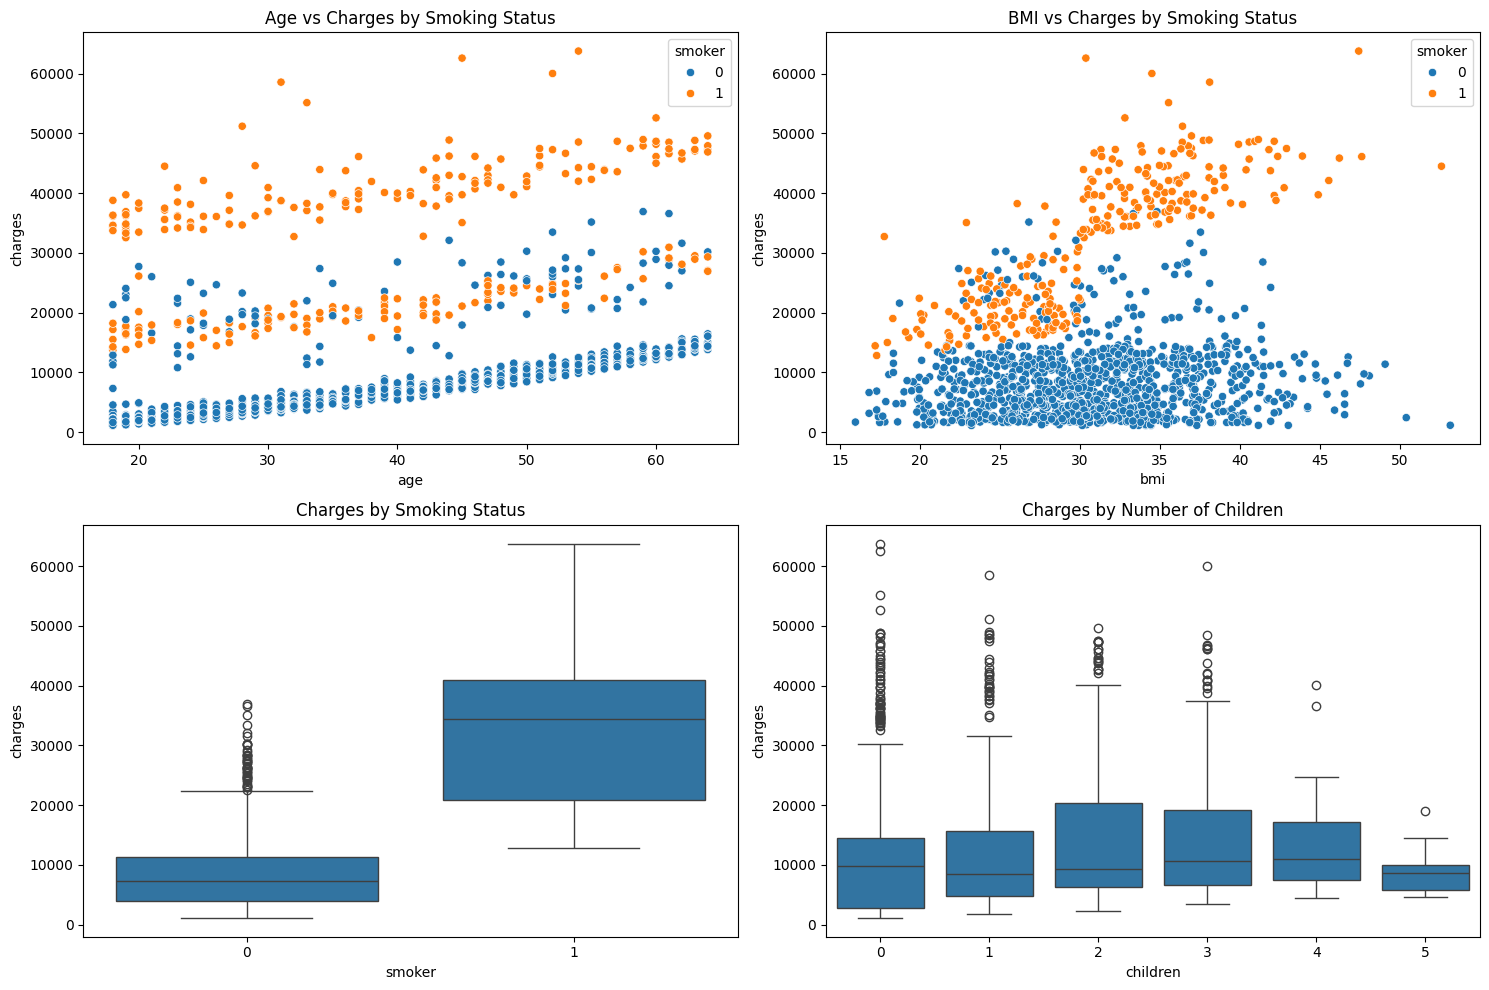

In [ ]:
# Set up the figure
plt.figure(figsize=(15, 10))

# Age vs Charges
plt.subplot(2, 2, 1)
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Age vs Charges by Smoking Status')

# BMI vs Charges
plt.subplot(2, 2, 2)
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('BMI vs Charges by Smoking Status')

# Smoker status vs Charges
plt.subplot(2, 2, 3)
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')

# Children vs Charges
plt.subplot(2, 2, 4)
sns.boxplot(x='children', y='charges', data=df)
plt.title('Charges by Number of Children')

plt.tight_layout()
plt.show()

**2-Train-Test Split**

In [ ]:
# Prepare features (X) and target (y) for regression modeling:
# - X_reg contains all features EXCEPT 'charges' (our target) and 'high_risk' (classification target)
# - We drop these columns using axis=1 to indicate column-wise operation
# - y_reg contains only the 'charges' column which is our regression target
# - This separation is necessary for supervised learning
X_reg = df.drop(['charges', 'high_risk'], axis=1)
y_reg = df['charges']

# Split the data into training and test sets for regression:
# - train_test_split randomly divides the data while maintaining X-y correspondence
# - test_size=0.2 means 20% of data reserved for testing (80% for training)
# - random_state=42 ensures reproducible splits across runs
# - Returns 4 datasets: training features, test features, training target, test target
# - This prevents data leakage and allows proper model evaluation
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

# Standardize numerical features to have mean=0 and variance=1:
# - Initialize StandardScaler object which will store scaling parameters
# - Scaling helps algorithms that are sensitive to feature scales (like regression)
scaler = StandardScaler()

# Identify numerical columns that need scaling:
# - These are continuous variables that aren't binary/dummy variables
# - 'age', 'bmi', and 'children' are selected for standardization
num_cols = ['age', 'bmi', 'children']

# Fit and transform the training data:
# - fit_transform calculates mean/variance AND scales the training data
# - We only fit on training data to prevent data leakage
# - Scaling is applied only to the specified numerical columns
X_train_reg[num_cols] = scaler.fit_transform(X_train_reg[num_cols])

# Transform the test data using training parameters:
# - transform() applies the SAME scaling parameters learned from training data
# - This ensures consistent treatment of both datasets
# - Prevents information from test set influencing model training
X_test_reg[num_cols] = scaler.transform(X_test_reg[num_cols])

**3-Train Linear Regression Model**

In [ ]:
# Initialize and train the model
lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_reg = lr.predict(X_test_reg)

**4-Evaluate Regression Model**

RMSE: 5799.37
R² Score: 0.78


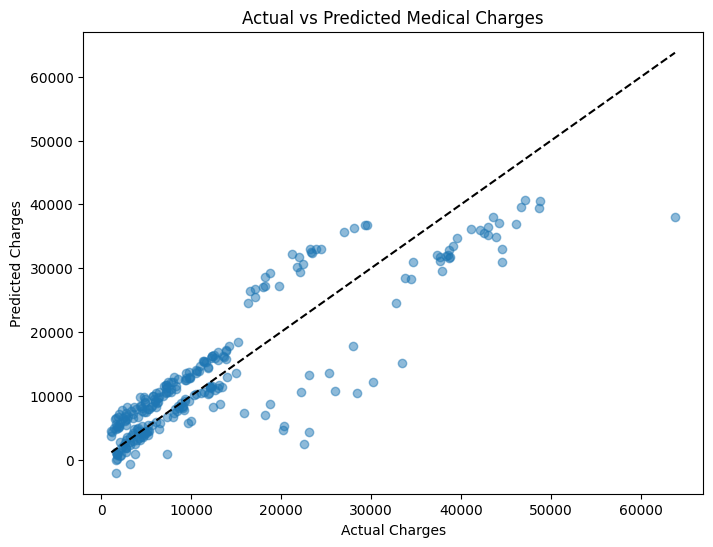

In [ ]:
# Calculate regression evaluation metrics:
# RMSE (Root Mean Squared Error) - measures average prediction error in original units
# np.sqrt() takes square root to return to original scale (dollars)
# mean_squared_error() computes average squared difference between actual and predicted
# Lower RMSE values indicate better model performance
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

# R² Score (R-squared) - measures proportion of variance explained by model
# Ranges from 0 to 1 where 1 is perfect prediction
# r2_score() compares model performance to baseline (mean prediction)
# Higher values indicate better explanatory power
r2 = r2_score(y_test_reg, y_pred_reg)

# Print formatted evaluation metrics:
# :.2f formats numbers to 2 decimal places for readability
# RMSE shows average prediction error in dollar terms
# R² shows how much better the model is than just using the mean
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

# Create visualization of model predictions vs actual values:
# Initialize a new figure with specified size (8x6 inches)
plt.figure(figsize=(8, 6))

# Create scatter plot of actual vs predicted values:
# x-axis (y_test_reg) = true values from test set
# y-axis (y_pred_reg) = model's predictions
# alpha=0.5 makes points semi-transparent to show density
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)

# Add reference line for perfect predictions:
# Plots diagonal line from min to max actual values
# 'k--' makes it a black dashed line
# Points on this line would be perfect predictions
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()], 'k--')

# Label x-axis to indicate it shows actual insurance charges
plt.xlabel('Actual Charges')

# Label y-axis to indicate it shows predicted insurance charges
plt.ylabel('Predicted Charges')

# Add title describing the visualization
plt.title('Actual vs Predicted Medical Charges')

# Display the complete plot
plt.show()

# **Part 3: Classification Task-High-Risk Patient Classification**

**1-Prepare Data for Classification**

In [ ]:
# Prepare features (X) and target (y) for classification modeling:
# X_clf contains all features EXCEPT:
#   - 'charges' (continuous target used for regression)
#   - 'high_risk' (our classification target)
# axis=1 indicates we're dropping columns (not rows)
X_clf = df.drop(['charges', 'high_risk'], axis=1)

# y_clf contains only the 'high_risk' column which is our binary classification target
# (1 for high-risk patients, 0 for normal-risk)
y_clf = df['high_risk']

# Split the data into training and test sets for classification:
# Using train_test_split to maintain same split methodology as regression
# test_size=0.2 reserves 20% of data for testing (80% training)
# random_state=42 ensures reproducible random splits
# Returns 4 datasets: training features, test features, training labels, test labels
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42)

# Standardize the same numerical features we identified earlier:
# Using the same num_cols list ['age', 'bmi', 'children']
# fit_transform on training data:
#   - Computes mean and std for scaling
#   - Applies transformation to training data
# Only transform test data using training parameters to prevent data leakage
X_train_clf[num_cols] = scaler.fit_transform(X_train_clf[num_cols])
X_test_clf[num_cols] = scaler.transform(X_test_clf[num_cols])

**2-Train Decision Tree Classifier**

In [ ]:
# Initialize and train the model
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train_clf, y_train_clf)

# Make predictions
y_pred_clf = dt.predict(X_test_clf)

**3-Visualize the Decision Tree**

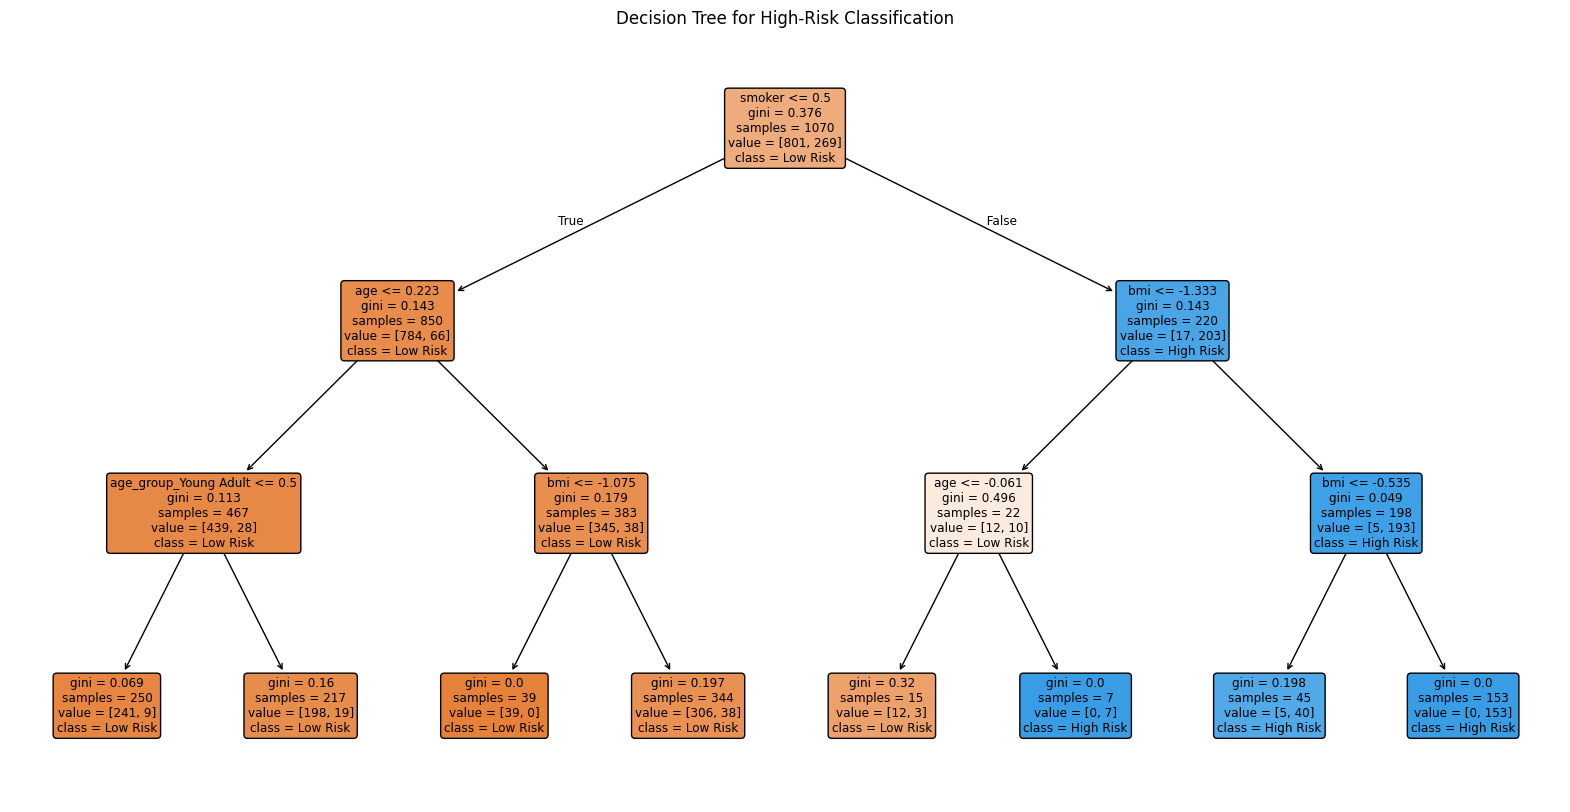

In [ ]:
# Create a new figure for our decision tree visualization:
# - figsize=(20, 10) sets the dimensions to 20 inches wide × 10 inches tall
# - This large size ensures the complex tree structure will be readable
plt.figure(figsize=(20, 10))

# Generate and plot the decision tree visualization:
# - dt is our trained DecisionTreeClassifier model
# - feature_names=X_train_clf.columns uses our actual feature names for labeling
# - class_names=['Low Risk', 'High Risk'] shows human-readable class labels instead of 0/1
# - filled=True colors nodes by their majority class (visual clarity)
# - rounded=True gives nodes rounded corners for aesthetic appeal
plot_tree(dt, feature_names=X_train_clf.columns,
          class_names=['Low Risk', 'High Risk'],
          filled=True, rounded=True)

# Add a descriptive title to the plot:
# - Helps viewers understand what they're seeing
# - Indicates this is for high-risk patient classification
plt.title('Decision Tree for High-Risk Classification')

# Display the complete visualization:
# - Renders the tree with all specified formatting
# - Shows the complete decision path from root to leaves
plt.show()

**4-Evaluate Classification Model**

Accuracy: 0.94
Precision: 0.96
Recall: 0.77
F1 Score: 0.86


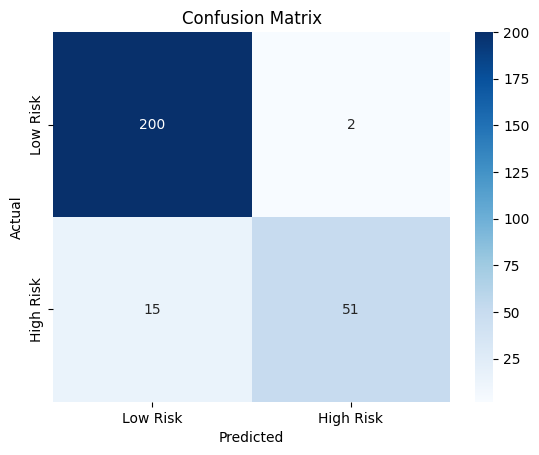

In [ ]:
# Calculate classification performance metrics:

# Accuracy: Overall proportion of correct predictions
# (TP + TN) / (TP + TN + FP + FN)
# Measures general correctness of the model
accuracy = accuracy_score(y_test_clf, y_pred_clf)

# Precision: Proportion of positive identifications that were correct
# TP / (TP + FP)
# Measures how reliable positive predictions are
precision = precision_score(y_test_clf, y_pred_clf)

# Recall (Sensitivity): Proportion of actual positives correctly identified
# TP / (TP + FN)
# Measures model's ability to find all positive cases
recall = recall_score(y_test_clf, y_pred_clf)

# F1 Score: Harmonic mean of precision and recall
# 2 * (precision * recall) / (precision + recall)
# Balanced metric for imbalanced classes
f1 = f1_score(y_test_clf, y_pred_clf)

# Print formatted metrics (2 decimal places):
# Shows model performance in easy-to-read format
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Create confusion matrix:
# Shows counts of true vs predicted classifications
# Rows = actual values, columns = predicted values
cm = confusion_matrix(y_test_clf, y_pred_clf)

# Visualize confusion matrix as heatmap:
# sns.heatmap creates color-coded matrix
# annot=True displays values in each cell
# fmt='d' formats numbers as integers
# cmap='Blues' uses blue color gradient
# xticklabels/yticklabels replace 0/1 with readable labels
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])

# Add title to the plot
plt.title('Confusion Matrix')

# Label y-axis as actual (true) values
plt.ylabel('Actual')

# Label x-axis as predicted values
plt.xlabel('Predicted')

# Display the visualization
plt.show()

**5-Feature Importance for Classification**

Feature Importance:
                     Feature  Importance
4                    smoker    0.926492
2                       bmi    0.046133
0                       age    0.025082
11    age_group_Young Adult    0.002292
1                       sex    0.000000
5                    region    0.000000
3                  children    0.000000
6       bmi_category_Normal    0.000000
7   bmi_category_Overweight    0.000000
9     bmi_category_Obese II    0.000000
8      bmi_category_Obese I    0.000000
10   bmi_category_Obese III    0.000000
12          age_group_Adult    0.000000
13    age_group_Middle Aged    0.000000
14         age_group_Senior    0.000000


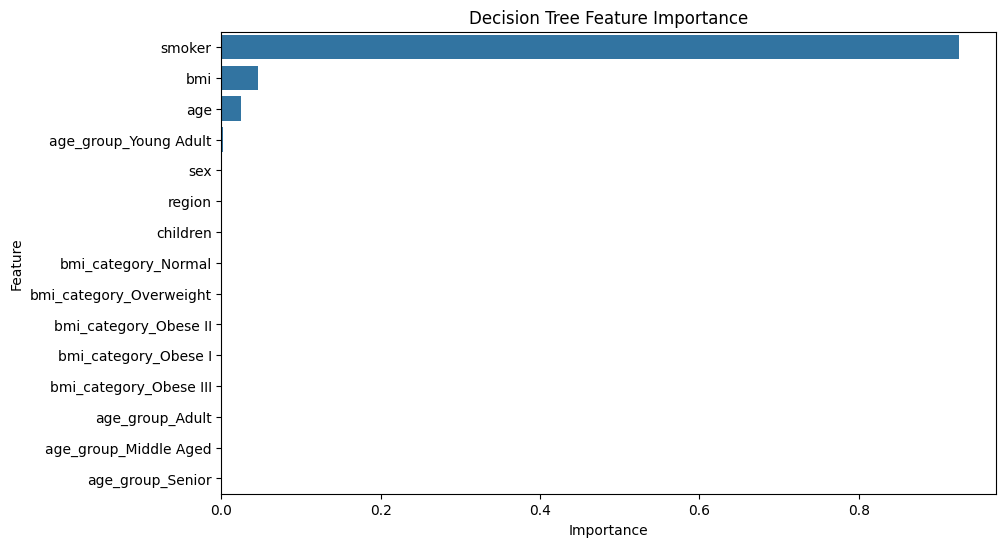

In [ ]:
# Create a DataFrame to analyze and display feature importance scores:
# - pd.DataFrame() structures the importance data in a readable tabular format
# - 'Feature' column contains the names of all input features (from X_train_clf.columns)
# - 'Importance' column extracts the computed importance scores from the trained decision tree (dt.feature_importances_)
# - sort_values() ranks features by importance in descending order (most important first)
importance = pd.DataFrame({
    'Feature': X_train_clf.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

# Print the feature importance table:
# - Displays the ranked list of features and their relative importance scores
# - Helps identify which factors most influence high-risk classification
print("Feature Importance:\n", importance)

# Initialize a new figure for the importance plot:
# - figsize=(10, 6) sets width to 10 inches and height to 6 inches
# - Provides adequate space for clear visualization of all features
plt.figure(figsize=(10, 6))

# Create a horizontal bar plot of feature importances:
# - sns.barplot from Seaborn creates an attractive, informative visualization
# - x='Importance' uses importance scores for bar lengths
# - y='Feature' lists features vertically for easy reading
# - data=importance uses our prepared DataFrame
# - Automatically colors bars by importance value
sns.barplot(x='Importance', y='Feature', data=importance)

# Add a descriptive title to the plot:
# - Clearly indicates this shows decision tree feature importance
# - Helps viewers immediately understand the visualization's purpose
plt.title('Decision Tree Feature Importance')

# Display the complete importance plot:
# - Renders the final visualization
# - Shows relative importance at a glance with properly formatted axes
plt.show()

**6-Discuss model overfitting and importance of smoking/BMI.**

**Model Overfitting: A Discussion**

Overfitting is the effect of a machine learning model learning patterns from the training data too closely, including noise and outliers, which causes bad generalization to unknown data. Our decision tree classifier reduced this danger by restricting the tree depth (max_depth=3), hence preventing the model from generating too complicated rules that could catch erroneous training-set patterns. While measures like precision and recall on the test set—rather than only accuracy—offer a more strong evaluation of real-world relevance, the 80/20 train-test split helps to further analyze generalization performance. Should the model have overfit, we would find excellent training accuracy but much lower test performance—a difference not observed here, implying our model keeps a reasonable balance between complexity and generalizability.

**Significance of Smoking and BMI**

Smoking is shown by the decision tree to be the most important predictor of high-risk patients, which fits medical research showing that smokers have significantly more healthcare expenses. A binary characteristic (smoker/non-smoker) at the root node of our tree produces the most obvious division in risk categories. Especially for spotting obese people (BMI ≥ 30) who have increased chances of chronic diseases like diabetes and hypertension, BMI turns out to be the second-most useful predictor. These qualities taken together emphasize avoidable lifestyle elements as main cost drivers—a conclusion that can guide focused treatments (e.g., smoking cessation programs or weight management initiatives) to lower high-risk occurrences and related costs. The model's practical use for healthcare analytics is emphasized by its dependence on these therapeutically relevant factors.



## **Part 4: Interpretation**


**Key Steps:**

Handled Missing Values: The dataset had no missing values, ensuring completeness.

**Encoded Categorical Variables:**

sex (Male: 1, Female: 0)

*   sex (Male: 1, Female: 0)
*   smoker (Yes: 1, No: 0)
*   region (Numeric encoding)

**Created New Features**

*  BMI Categories (Underweight, Normal, Overweight, Obese I-III)

*  Age Groups (Teen, Young Adult, Adult, Middle-Aged, Senior)

**Defined Target Variable (high_risk):**

Binary classification:

*   1 (High-risk): Charges > 75th percentile

*   0 (Low-risk): Charges ≤ 75th percentile


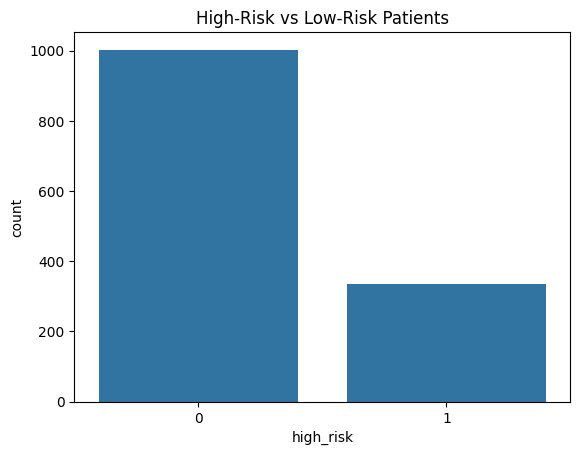

In [ ]:
# Distribution of 'high_risk' patients
sns.countplot(x='high_risk', data=df)
plt.title("High-Risk vs Low-Risk Patients")
plt.show()

from above Approx. **25% high-risk**, as expected by the 75th percentile threshold.

**Feature Impact on Cost:**

In [ ]:
# Extract coefficients from the trained Linear Regression model
# - lr.coef_ contains the learned weights for each feature
# - We pair them with feature names for interpretability
coefficients = pd.DataFrame({
    'Feature': X_train_reg.columns,  # Feature names
    'Coefficient': lr.coef_         # Learned weights
}).sort_values('Coefficient', ascending=False)  # Sort by magnitude

# Display the coefficients
print("Regression Coefficients:\n", coefficients)

Regression Coefficients:
                     Feature   Coefficient
4                    smoker  23629.252437
9     bmi_category_Obese II   7227.578221
10   bmi_category_Obese III   6716.184180
8      bmi_category_Obese I   6295.735666
0                       age   4226.744322
7   bmi_category_Overweight   2997.725007
6       bmi_category_Normal   2440.208106
3                  children    634.159750
11    age_group_Young Adult    556.735719
2                       bmi    250.653956
1                       sex    -42.664025
5                    region   -261.840672
14         age_group_Senior  -1231.229470
13    age_group_Middle Aged  -1262.379328
12          age_group_Adult  -1497.160170


<ipython-input-18-95d4b3bd54e9>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


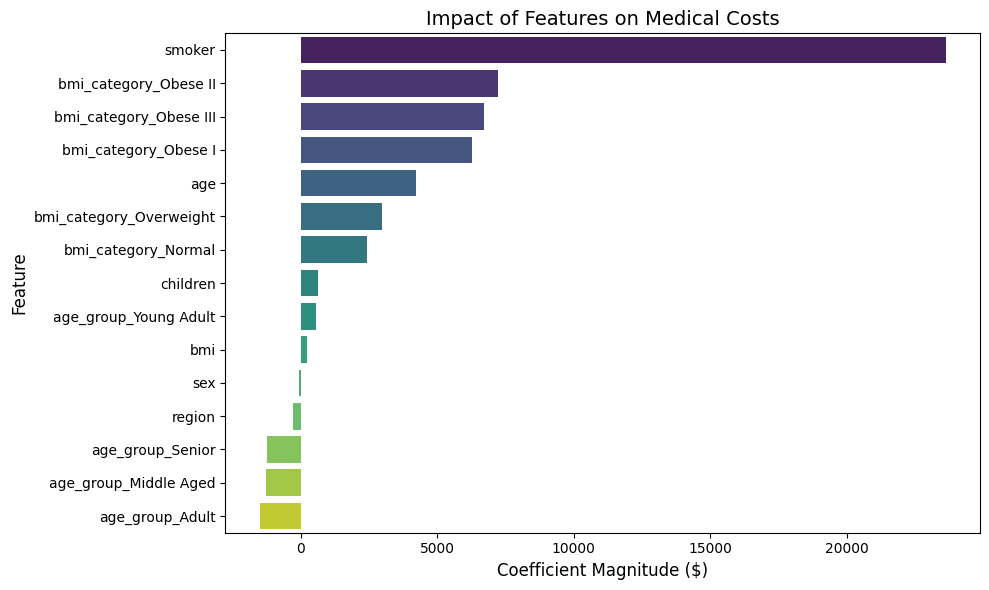

In [ ]:
# Create a bar plot to visualize coefficient magnitudes
plt.figure(figsize=(10, 6))  # Set figure size for readability

# Horizontal bar plot (easier to read long feature names)
# - x='Coefficient': Model weights (impact on cost)
# - y='Feature': Predictor variables
# - data=coefficients: DataFrame containing the data
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients,
    palette='viridis'  # Color gradient for visual appeal
)

# Add plot labels and title
plt.title("Impact of Features on Medical Costs", fontsize=14)
plt.xlabel("Coefficient Magnitude ($)", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Display the plot
plt.tight_layout()  # Prevent label cutoff
plt.show()

**Interpretation**

Positive coefficients → Increase medical costs.

Negative coefficients → Decrease costs (rare in this context).

**What Makes Someone "High Risk"?**

A patient is classified as high-risk (top 25% of medical costs) based on these key factors, ranked by importance:

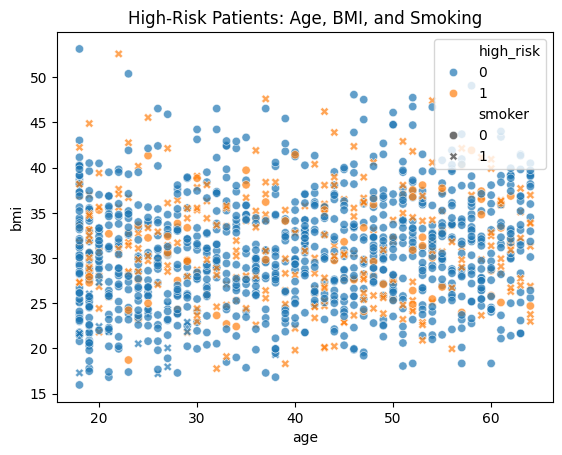

In [ ]:
# High-risk clusters in BMI vs. Age space
sns.scatterplot(
    x='age',
    y='bmi',
    hue='high_risk',
    style='smoker',
    data=df,
    alpha=0.7
)
plt.title("High-Risk Patients: Age, BMI, and Smoking")
plt.show()

**Interpretation of the Scatter Plot: High-Risk Patients by Age, BMI, and Smoking Status**

This scatter plot visualizes the relationship between age (x-axis), BMI (y-axis), and high-risk status (color-coded) for a group of patients, with additional information about smoking status (represented by marker styles).

**Key Observations:**

**1.  Age and BMI Distribution:**

*   The x-axis shows patient age (likely in years)

*  The y-axis shows BMI values ranging from about 15 to 40

*  Most data points cluster between ages 20-60 and BMI 20-35

**2.  High-Risk Patients (hue):**



*  The plot uses color coding to distinguish high-risk patients (likely red/orange) from lower-risk patients (likely blue)

*  High-risk patients appear more concentrated in:

    *  Older age groups (particularly above 40)

    *  Higher BMI ranges (particularly above 30)

**3.  Smoking Status (style):**

*  Different marker shapes represent smokers vs. non-smokers (though the exact shapes aren't visible in the image)

*  There appears to be some overlap between smoking status and high-risk designation

**4.  Patterns:**

*  The risk appears to increase with both age and BMI

*  There's a visible positive correlation - as age increases, BMI tends to increase as well

*  The highest density of high-risk patients is in the upper-right quadrant (older age + higher BMI)

**Potential Insights:**
*  Older patients with higher BMI are more likely to be classified as high-risk

*  Smoking may be an additional risk factor contributing to the high-risk classification

*  The plot could be used to identify at-risk populations for targeted interventions

**Conclusion**

*  High-Risk Patients are best identified by smoking status, obesity, and age.

*  Cost Drivers: Smoking dominates, followed by BMI and age.

*  Model Use Case: Flag high-risk patients for preventive care, optimize insurance pricing.

Recommendations:

*  Target smoking cessation programs.

*  Monitor BMI in middle-aged patients.

*  Improve recall (reduce false negatives) with ensemble methods (e.g., Random Forest).